<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/exercises/P1-MovieGenrePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Movie Genre Classification

Classify a movie genre based on its plot.

<img src="https://raw.githubusercontent.com/sergiomora03/AdvancedTopicsAnalytics/main/notebooks/img/moviegenre.png"
     style="float: left; margin-right: 10px;" />



### Data

Input:
- movie plot

Output:
Probability of the movie belong to each genre


### Evaluation

- 30% Report with all the details of the solution, the analysis and the conclusions. The report cannot exceed 10 pages, must be send in PDF format and must be self-contained.
- 30% Code with the data processing and models developed that support the reported results.
- 30% Presentation of no more than 15 minutes with the main results of the project.
- 10% Model performance achieved. Metric: "AUC".

• The project must be carried out in groups of 4 people.
• Use clear and rigorous procedures.
• The delivery of the project is on March 15th, 2024, 11:59 pm, through email with Github link.
• No projects will be received after the delivery time or by any other means than the one established.




### Acknowledgements

We thank Professor Fabio Gonzalez, Ph.D. and his student John Arevalo for providing this dataset.

See https://arxiv.org/abs/1702.01992

## Sample Submission

In [1]:
!pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 8.6 MB/s eta 0:00:00


In [2]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.1 MB/s eta 0:00:00


In [3]:
!pip install langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [153]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import spacy
nlp = spacy.load("en_core_web_sm")

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

from xgboost import XGBClassifier
from optuna.trial import TrialState
import optuna

import contractions
from langdetect import detect

from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [84]:
def remove_stopwords(text):
  stop_words = set(stopwords.words('english'))
  words = text.split()
  filtered_words = [word for word in words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()
    fdist = nltk.FreqDist(all_words)

    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })

    d = words_df.nlargest(columns="count", n=terms)

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data=d, x="count", y="word", hue="word", palette='viridis', legend=False)
    ax.set(ylabel='Palabra', xlabel='Frecuencia', title='Palabras más frecuentes')
    plt.tight_layout()
    plt.show()

def plot_most_freq(vect, X_dtm):

  feature_names = vect.get_feature_names_out()
  word_counts = X_dtm.sum(axis=0).A1

  word_freq = pd.DataFrame({'word': feature_names, 'count': word_counts})
  word_freq = word_freq.sort_values(by='count', ascending=False)

  plt.figure(figsize=(14, 6))
  sns.barplot(data=word_freq.head(30), x='word', y='count', palette='viridis')
  plt.xticks(rotation=45)
  plt.title('Top 30 Most Frequent Words')
  plt.xlabel('Word')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

def plot_classes_freq(y_genres, le):
    genre_counts = pd.Series(y_genres.sum(axis=0), index=le.classes_).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    ax = genre_counts.plot(kind='bar', color='skyblue')

    plt.title('Genre Occurrences in Training Data')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    # Add data labels
    for i, value in enumerate(genre_counts):
        ax.text(i, value + 1, str(int(value)), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_co_occurrence(y_genres, le):
  co_occurrence = pd.DataFrame(y_genres.T @ y_genres, index=le.classes_, columns=le.classes_)

  plt.figure(figsize=(12, 10))
  sns.heatmap(co_occurrence, cmap='Blues', annot=True, fmt='d')
  plt.title('Genre Combination Heatmap')
  plt.xlabel('Genre')
  plt.ylabel('Genre')
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

def group_genres(genre_list_str):
    import ast

    try:
        genres = ast.literal_eval(genre_list_str)
        if not isinstance(genres, list):
            return []
    except:
        return []

    # Remove unwanted genres
    genres = [g for g in genres if g not in {'News', 'Short'}]

    # Define genre groupings (if needed)
    genre_groups = {
        'Drama-Crime': ['Drama', 'Crime'],
        'Romance-Drama': ['Romance', 'Drama'],
        'Romance-Comedy': ['Romance', 'Comedy'],
        'Thriller-Action': ['Thriller', 'Action'],
        'Thriller-Crime': ['Thriller', 'Crime'],
        'Thriller-Mystery': ['Thriller', 'Mystery'],
        'Adventure-Action': ['Adventure', 'Action'],
        'Drama-Action': ['Drama', 'Action'],
        'Family-Comedy': ['Family', 'Comedy'],
        'Thriller-Horror': ['Thriller', 'Horror'],
        'Fantasy-SciFi': ['Fantasy', 'Sci-Fi'],
        'Music-Musical': ['Music', 'Musical'],
        'History-War': ['History', 'War']
    }

    # Create a reverse mapping
    group_membership = {
        genre: group
        for group, members in genre_groups.items()
        for genre in members
    }

    # Apply groupings
    genres_set = set(genres)
    result = set()
    used_genres = set()

    for group_name, members in genre_groups.items():
        if genres_set.intersection(members):
            result.add(group_name)
            used_genres.update(members)

    # Include ungrouped genres as-is
    ungrouped = genres_set - used_genres
    result.update(ungrouped)

    # Now filter to keep only top 8, rest to 'Other'
    top_8 = {
        'Documentary',
        'Western',
        'History-War',
        'Sport',
        'Animation',
        'Film-Noir',
        'Thriller-Horror',
        'Adventure-Action'
    }

    reduced_result = []
    for r in result:
        if r in top_8:
            reduced_result.append(r)
        else:
            reduced_result.append('Other')

    return list(set(reduced_result))


def expand_contractions(text):
    return contractions.fix(text)

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

def cleanData(data):
    data['clean_plot'] = data['plot']

    # Fix possessives and contractions early (e.g., bullard ' s → bullard's)
    data['clean_plot'] = data['clean_plot'].str.replace(
        r"\b([A-Za-z0-9]+)\s*'\s*([A-Za-z0-9]+)\b", r"\1'\2", regex=True
    )

    # Normalize whitespace around apostrophes
    data['clean_plot'] = data['clean_plot'].str.replace(r"\s*'\s*", "'", regex=True)

    # Remove . , - (optional: you might remove these together with punctuation below)
    data['clean_plot'] = data['clean_plot'].str.replace(r"[.,-]", '', regex=True)

    # Remove all punctuation except apostrophes and spaces
    data['clean_plot'] = data['clean_plot'].str.replace(r"[^A-Za-z0-9' ]+", '', regex=True)

    # Normalize whitespace
    data['clean_plot'] = data['clean_plot'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Expand contractions
    data['clean_plot'] = data['clean_plot'].apply(expand_contractions)

    # Lemmatize
    data['clean_plot'] = data['clean_plot'].apply(lemmatize_text)

    # Remove stopwords
    data['clean_plot'] = data['clean_plot'].apply(remove_stopwords)

    # Lowercase (after lemmatization and stopwords)
    data['clean_plot'] = data['clean_plot'].str.lower()

    # Filter only English plots
    data = data[data['clean_plot'].apply(is_english)].reset_index(drop=True)

    # Replace apostrophes inside words with a space (e.g., travis'death → travis death)
    data['clean_plot'] = data['clean_plot'].str.replace(r"(?<=[A-Za-z])'(?=[A-Za-z])", ' ', regex=True)

    # Remove single letters (unless you want to keep e.g. "I")
    data['clean_plot'] = data['clean_plot'].str.replace(r'\b\w\b', '', regex=True)

    # Final cleanup: remove any leftover non-letter chars and normalize spaces again
    data['clean_plot'] = data['clean_plot'].str.replace(r'[^A-Za-z ]+', '', regex=True)
    data['clean_plot'] = data['clean_plot'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Remove Names
    # data['clean_plot'] = data['clean_plot'].apply(remove_names)

    return data



def lemmatize_text(text):
  doc = nlp(text)
  return ' '.join([token.lemma_ for token in doc if token.lemma_ != '-PRON-'])

def remove_names(text):
    doc = nlp(text)
    return ' '.join([token.text for token in doc if token.ent_type_ != 'PERSON'])

# Define custom tokenizer
def nltk_tokenizer(text):
    return word_tokenize(text)

def data_preprocessing(dataTraining, dataTesting):

  vect = TfidfVectorizer(
      ngram_range=(1, 3),          # Incluir también trigramas 1,3
      max_features=1000,           # Aumentar el número de características 1000
      min_df=50,                   # Ignorar términos que aparecen en menos de 50 documentos
      # max_df=0.3,                # Ignorar términos que aparecen en más del 70% de documentos
      sublinear_tf=True,           # Aplicar escala sublinear a term frequency (1+log(tf))
      norm='l2'                    # Normalización L2 para cada vector
      # stop_words='english'       # Eliminar palabras vacías
  )

  # Cleaning and preprocessing — TRAINING
  dataTraining = cleanData(dataTraining)
  X_dtm = vect.fit_transform(dataTraining['clean_plot'])


  # Cleaning and preprocessing — TESTING
  dataTesting = cleanData(dataTesting)
  X_val = vect.transform(dataTesting['clean_plot'])

  dataTraining['grouped_genres'] = dataTraining['genres'].apply(group_genres)
  # dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
  le = MultiLabelBinarizer()
  y_genres = le.fit_transform(dataTraining['grouped_genres'])

  # Train/test split
  X_train, X_test, y_train_genres, y_test_genres = train_test_split(
      X_dtm, y_genres, test_size=0.33, random_state=42
  )
  print("Training data\n")
  for i, genre in enumerate(le.classes_):
    print(f"{i}: {genre}")
  # display(dataTraining)

  print("\n")
  plot_classes_freq(y_genres, le)

  print("\n")
  plot_most_freq(vect, X_dtm)
  print("\n")

  plot_co_occurrence(y_genres, le)
  print("\n")

  print("Validation data\n")
  display(dataTesting)

  return X_train, X_test, y_train_genres, y_test_genres, X_val, vect, dataTraining, dataTesting


In [85]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0, dtype=str)
dataTesting = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0, dtype=str)

Training data

0: Adventure-Action
1: Animation
2: Documentary
3: Film-Noir
4: History-War
5: Other
6: Sport
7: Thriller-Horror
8: Western




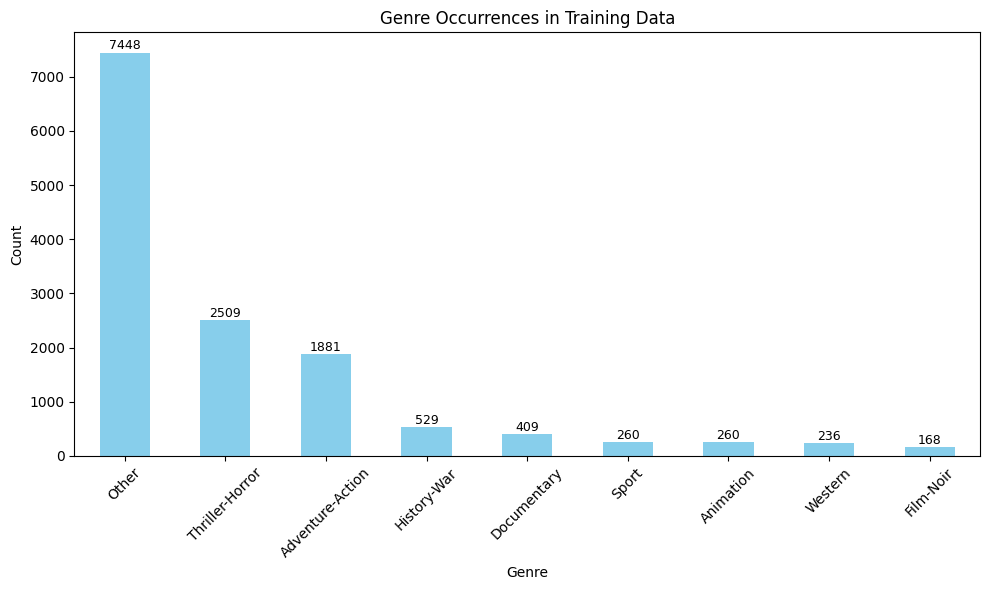

<ipython-input-84-d6c055665393>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq.head(30), x='word', y='count', palette='viridis')


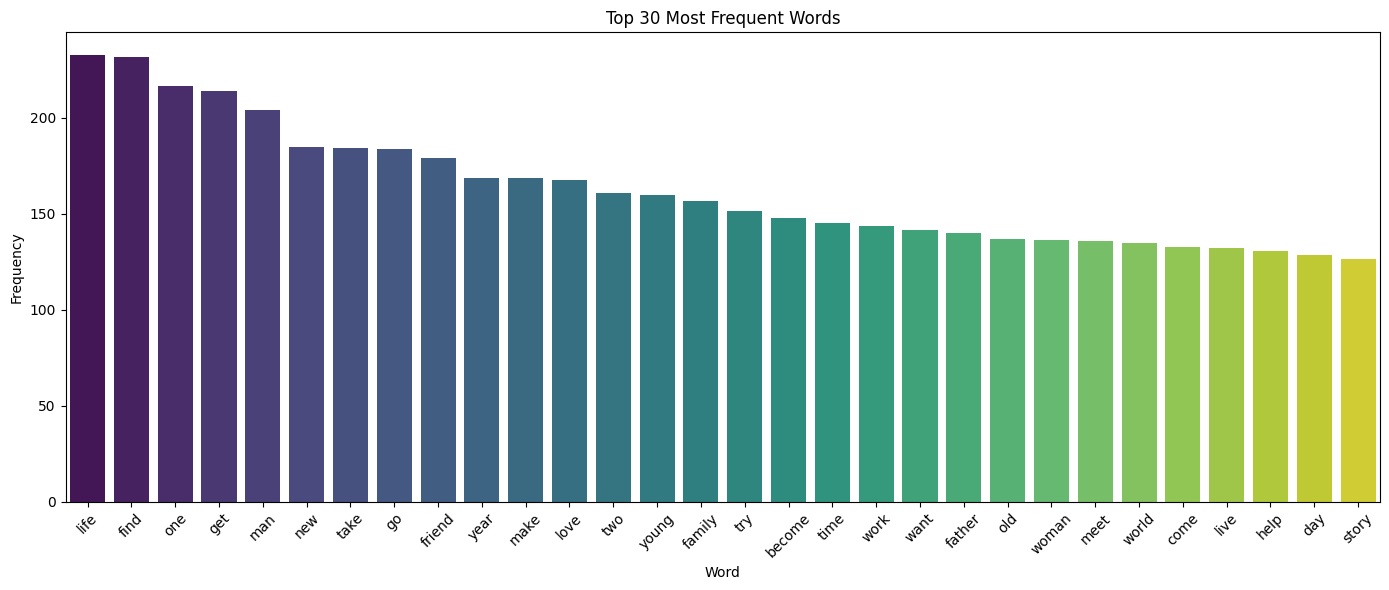

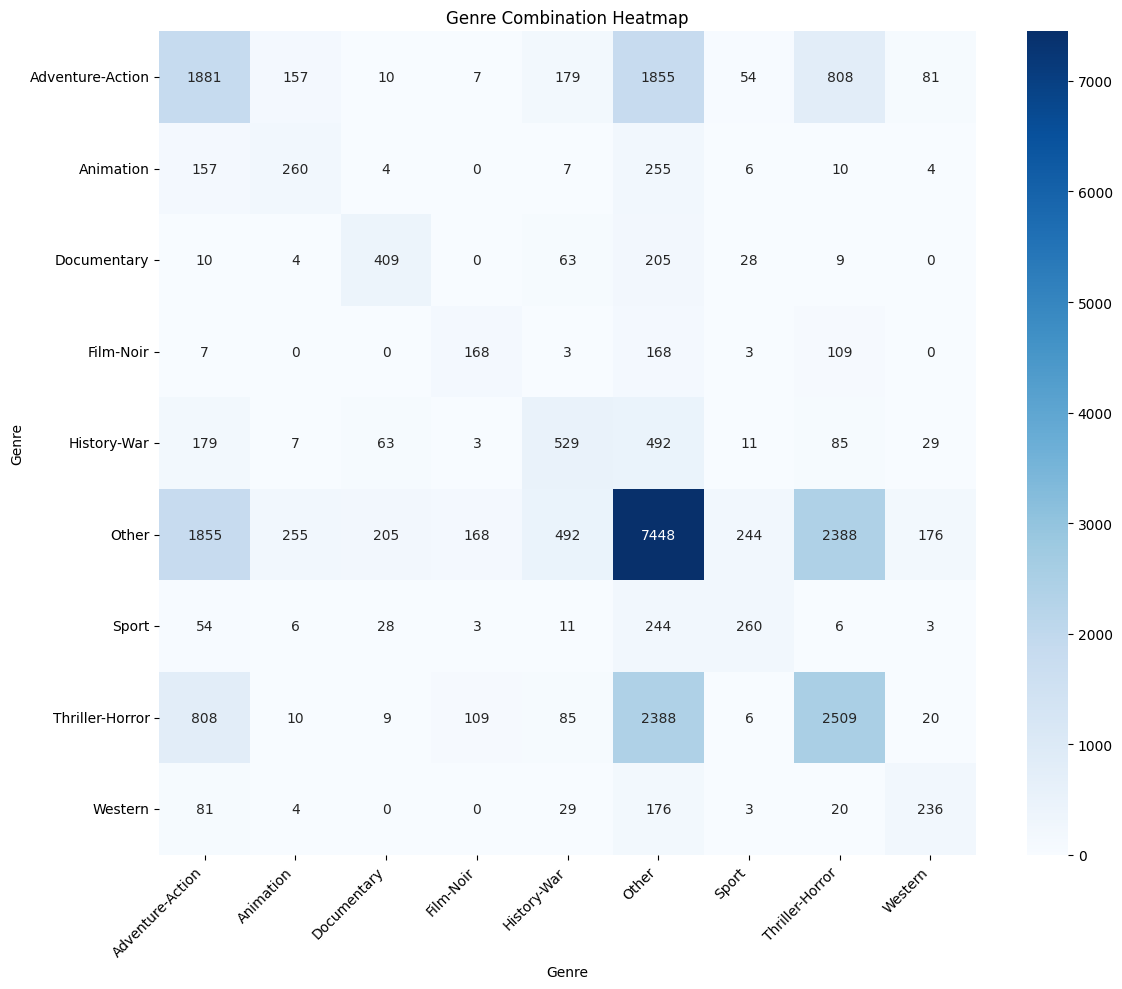



Validation data



,year,title,plot,clean_plot
0,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ....",meet fate shall seal fate theresa osborne run ...
1,1978,Midnight Express,"the true story of billy hayes , an american c...",true story billy haye american college student...
2,1996,Primal Fear,martin vail left the chicago da ' s office to ...,martin vail leave chicago da office become suc...
3,1950,Crisis,husband and wife americans dr . eugene and mr...,husband wife americans dr eugene mrs helen fer...
4,1959,The Tingler,the coroner and scientist dr . warren chapin ...,coroner scientist dr warren chapin research sh...
...,...,...,...,...
3365,2008,The Fifth Commandment,"in bangkok , an assassin who turns down a job...",bangkok assassin turn job hit close home find ...
3366,2003,Coffee and Cigarettes,eleven separate vignettes are presented . in ...,eleven separate vignette present celebrity pla...
3367,1957,Pal Joey,"joey evans is charming , handsome , funny , ...",joey evans charming handsome funny talented fi...
3368,2002,Jonah: A VeggieTales Movie,when the singing veggies encounter some car tr...,singing veggie encounter car trouble strand ol...


In [86]:
X_train, X_test, y_train_genres, y_test_genres, X_val, vect, dataTrainingP, dataTestingP = data_preprocessing(dataTraining, dataTesting)

# Random Forest

In [149]:
def create_model(trial):
    max_depth = trial.suggest_int("max_depth", 3, 15)
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    min_samples_split = trial.suggest_int("min_samples_split", 3, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 3, 20)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 10, 100)


    clf = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_leaf_nodes=max_leaf_nodes,
            n_jobs=-1,
            random_state=42
        ),
        n_jobs=-1
    )
    return clf

def objective(trial):
    global X_train, y_train_genres, X_test, y_test_genres  # You only need training data for CV

    # Create and train model
    model = create_model(trial)
    model.fit(X_train, y_train_genres)

    # Predict probabilities
    y_train_pred = model.predict_proba(X_train)
    y_valid_pred = model.predict_proba(X_test)

    # Compute AUC
    train_auc = roc_auc_score(y_train_genres, y_train_pred, average='macro')
    valid_auc = roc_auc_score(y_test_genres, y_valid_pred, average='macro')

    overFit = train_auc - valid_auc

    print(f"Train AUC: {np.mean(train_auc):.4f}, Validation AUC: {np.mean(valid_auc):.4f}")

    return valid_auc - overFit * 2

# Función principal de entrenamiento con Optuna
def main(n_trials):
    prune = optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=10,
        interval_steps=1
    )
    study = optuna.create_study(direction="maximize", pruner=prune)
    study.optimize(objective, n_trials=n_trials)

    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("\nBest trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    return trial

In [150]:
best_trial = main(100)

[I 2025-04-08 01:26:44,535] A new study created in memory with name: no-name-29f93245-508d-4613-bd26-3eeeed04059c
[I 2025-04-08 01:26:47,966] Trial 0 finished with value: 0.6744017219099646 and parameters: {'max_depth': 9, 'n_estimators': 80, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_leaf_nodes': 35}. Best is trial 0 with value: 0.6744017219099646.


Train AUC: 0.9356, Validation AUC: 0.8485


[I 2025-04-08 01:26:49,655] Trial 1 finished with value: 0.6334466339004147 and parameters: {'max_depth': 14, 'n_estimators': 93, 'max_features': 'log2', 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_leaf_nodes': 52}. Best is trial 0 with value: 0.6744017219099646.


Train AUC: 0.9552, Validation AUC: 0.8480


[I 2025-04-08 01:26:52,896] Trial 2 finished with value: 0.6480810877521962 and parameters: {'max_depth': 11, 'n_estimators': 175, 'max_features': 'sqrt', 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_leaf_nodes': 96}. Best is trial 0 with value: 0.6744017219099646.


...

Train AUC: 0.9057, Validation AUC: 0.8448


[I 2025-04-08 01:31:00,446] Trial 98 finished with value: 0.7234965710212791 and parameters: {'max_depth': 3, 'n_estimators': 184, 'max_features': 'sqrt', 'min_samples_split': 3, 'min_samples_leaf': 20, 'max_leaf_nodes': 10}. Best is trial 98 with value: 0.7234965710212791.


Train AUC: 0.9058, Validation AUC: 0.8450


[I 2025-04-08 01:31:03,659] Trial 99 finished with value: 0.7144239104389222 and parameters: {'max_depth': 13, 'n_estimators': 191, 'max_features': 'sqrt', 'min_samples_split': 3, 'min_samples_leaf': 20, 'max_leaf_nodes': 10}. Best is trial 98 with value: 0.7234965710212791.


Train AUC: 0.9212, Validation AUC: 0.8523
Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  0
  Number of complete trials:  100

Best trial:
  Value:  0.7234965710212791
  Params: 
    max_depth: 3
    n_estimators: 184
    max_features: sqrt
    min_samples_split: 3
    min_samples_leaf: 20
    max_leaf_nodes: 10


[I 2025-04-07 23:51:52,834] Trial 94 finished with value: 0.8397558697668114 and parameters: {'max_depth': 12, 'n_estimators': 195, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_leaf_nodes': 32}. Best is trial 94 with value: 0.8397558697668114.

In [154]:
def rfc(X_train, y_train_genres):

  clf = OneVsRestClassifier(
      RandomForestClassifier(
          n_estimators=184,
          max_depth=3,
          max_features="sqrt",
          min_samples_split=3,
          min_samples_leaf=20,
          max_leaf_nodes=10,
          n_jobs=-1,
          random_state=42
      ),
      n_jobs=-1
  )
  clf.fit(X_train, y_train_genres)

  return clf

clf = rfc(X_train, y_train_genres)

## Resultados del Random Forest

In [161]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf.predict_proba(X_train)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other    0.94864  1.000000  0.973643  0.948640  0.885079
7   Thriller-Horror    1.00000  0.009009  0.017857  0.686133  0.831150
0  Adventure-Action    0.00000  0.000000  0.000000  0.755374  0.842470
1         Animation    0.00000  0.000000  0.000000  0.967091  0.912315
2       Documentary    0.00000  0.000000  0.000000  0.947879  0.946967
4       History-War    0.00000  0.000000  0.000000  0.932661  0.904411
3         Film-Noir    0.00000  0.000000  0.000000  0.979836  0.936645
6             Sport    0.00000  0.000000  0.000000  0.964619  0.937001
8           Western    0.00000  0.000000  0.000000  0.970325  0.955735

##### Global Metrics #####
Macro Precision: 0.2165
Macro Recall:    0.1121
Macro F1-Score:  0.1102
Macro AUC:  0.9058


In [162]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf.predict_proba(X_test)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.950193  1.000000  0.974461  0.950193  0.779969
7   Thriller-Horror   1.000000  0.004739  0.009434  0.675676  0.802051
0  Adventure-Action   0.000000  0.000000  0.000000  0.770270  0.794758
1         Animation   0.000000  0.000000  0.000000  0.966409  0.790020
2       Documentary   0.000000  0.000000  0.000000  0.947876  0.923097
4       History-War   0.000000  0.000000  0.000000  0.932432  0.880783
3         Film-Noir   0.000000  0.000000  0.000000  0.976062  0.828948
6             Sport   0.000000  0.000000  0.000000  0.971429  0.877242
8           Western   0.000000  0.000000  0.000000  0.969112  0.928137

##### Global Metrics #####
Macro Precision: 0.2167
Macro Recall:    0.1116
Macro F1-Score:  0.1093
Macro AUC:  0.8450


# Regresón Logistica

In [173]:
def create_model(trial):

  l1_ratio = trial.suggest_float("l1_ratio", 0, 1)
  # iter = trial.suggest_int("iter", 50, 1000)
  c = trial.suggest_float("c", 0, 2)

  model = OneVsRestClassifier(
        LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=l1_ratio,
        C=c,
        max_iter=250,
        n_jobs=-1
    ),
    n_jobs=-1
  )

  return model

def objective(trial):
    global X_train, y_train_genres, X_test, y_test_genres  # You only need training data for CV

    # Create and train model
    model = create_model(trial)
    model.fit(X_train, y_train_genres)

    # Predict probabilities
    y_train_pred = model.predict_proba(X_train)
    y_valid_pred = model.predict_proba(X_test)

    # Compute AUC
    train_auc = roc_auc_score(y_train_genres, y_train_pred, average='macro')
    valid_auc = roc_auc_score(y_test_genres, y_valid_pred, average='macro')

    overFit = train_auc - valid_auc

    print(f"Train AUC: {np.mean(train_auc):.4f}, Validation AUC: {np.mean(valid_auc):.4f}")

    return valid_auc - overFit * 1.5

def main(n_trials):
    prune = optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=10,
            interval_steps=1
        )
    study = optuna.create_study(direction="maximize", pruner=prune)
    study.optimize(objective, n_trials=n_trials)
    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    print("Study statistics: ")
    print("  Number of finished trials: ", len(study.trials))
    print("  Number of pruned trials: ", len(pruned_trials))
    print("  Number of complete trials: ", len(complete_trials))

    print("\nBest trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    return trial

In [174]:
best_trial = main(100)

[I 2025-04-08 02:07:55,597] A new study created in memory with name: no-name-ea778dd4-607c-433f-85d0-8c619c34cb0c
[I 2025-04-08 02:08:00,484] Trial 0 finished with value: 0.8095589702463551 and parameters: {'l1_ratio': 0.07672662818517739, 'c': 0.5864953653096381}. Best is trial 0 with value: 0.8095589702463551.


Train AUC: 0.9525, Validation AUC: 0.8953


[I 2025-04-08 02:08:03,814] Trial 1 finished with value: 0.7927629243352107 and parameters: {'l1_ratio': 0.22991664525102906, 'c': 1.251744333185529}. Best is trial 0 with value: 0.8095589702463551.


Train AUC: 0.9604, Validation AUC: 0.8934


[I 2025-04-08 02:08:06,092] Trial 2 finished with value: 0.7946897154881778 and parameters: {'l1_ratio': 0.44173343856457414, 'c': 1.1706673130123386}. Best is trial 0 with value: 0.8095589702463551.


...

Train AUC: 0.9320, Validation AUC: 0.8890


[I 2025-04-08 02:10:51,597] Trial 98 finished with value: 0.824616438126442 and parameters: {'l1_ratio': 0.04157420854685086, 'c': 0.11671654589253402}. Best is trial 88 with value: 0.8269578599311436.


Train AUC: 0.9256, Validation AUC: 0.8852


[I 2025-04-08 02:10:55,860] Trial 99 finished with value: 0.7903056466071126 and parameters: {'l1_ratio': 0.04805124663465765, 'c': 1.2515485178653483}. Best is trial 88 with value: 0.8269578599311436.


Train AUC: 0.9655, Validation AUC: 0.8954
Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  0
  Number of complete trials:  100

Best trial:
  Value:  0.8269578599311436
  Params: 
    l1_ratio: 0.025788643604311347
    c: 0.04009053725943472


[I 2025-04-08 02:09:14,261] Trial 43 finished with value: 0.8173380044594953 and parameters: {'l1_ratio': 0.11398855176756906, 'c': 0.4058035200843805}. Best is trial 42 with value: 0.8229122952029246.
Train AUC: 0.9402, Validation AUC: 0.8911

In [175]:
def lr(X_train, y_train_genres):

  clf = OneVsRestClassifier(
        LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.11398855176756906,   # 0.5 = 50% L1, 50% L2
        C=0.4058035200843805,
        max_iter=1000
    ),
    n_jobs=-1
  )
  clf.fit(X_train, y_train_genres)
  return clf
clf1 = lr(X_train, y_train_genres)

## Resultados de la Regresión Logistica

In [176]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf1.predict_proba(X_train)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Train#####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.949001  1.000000  0.973833  0.949020  0.910770
7   Thriller-Horror   0.846723  0.481081  0.613558  0.808065  0.897800
0  Adventure-Action   0.873211  0.332037  0.481127  0.824805  0.903278
2       Documentary   0.976744  0.153285  0.264984  0.955678  0.975734
4       History-War   0.960000  0.067797  0.126649  0.937036  0.946219
6             Sport   1.000000  0.037634  0.072539  0.965950  0.960385
1         Animation   0.000000  0.000000  0.000000  0.967091  0.953870
3         Film-Noir   0.000000  0.000000  0.000000  0.979836  0.941819
8           Western   0.000000  0.000000  0.000000  0.970325  0.971986

##### Global Metrics #####
Macro Precision: 0.6229
Macro Recall:    0.2302
Macro F1-Score:  0.2814
Macro AUC:  0.9402


In [177]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = clf1.predict_proba(X_test)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.950560  1.000000  0.974653  0.950579  0.834882
7   Thriller-Horror   0.806373  0.389810  0.525559  0.770656  0.859406
0  Adventure-Action   0.738739  0.275630  0.401469  0.811197  0.848494
2       Documentary   0.904762  0.140741  0.243590  0.954440  0.963476
4       History-War   0.916667  0.062857  0.117647  0.936293  0.909634
3         Film-Noir   0.000000  0.000000  0.000000  0.976062  0.881431
1         Animation   0.000000  0.000000  0.000000  0.966409  0.856692
6             Sport   0.000000  0.000000  0.000000  0.971429  0.932083
8           Western   0.000000  0.000000  0.000000  0.969112  0.933481

##### Global Metrics #####
Macro Precision: 0.4797
Macro Recall:    0.2077
Macro F1-Score:  0.2514
Macro AUC:  0.8911


#Multinomial Naive Bayes

In [179]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import MultinomialNB
nb_classifier = OneVsRestClassifier(MultinomialNB()) #OneVsRestClassifier(
nb_classifier.fit(X_train, y_train_genres)

OneVsRestClassifier(estimator=MultinomialNB())

## Resultados del modelo Multinomial Naive Bayes

In [181]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = nb_classifier.predict_proba(X_train)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_train_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_train_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_train_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Train" + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_train_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_train_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Train#####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.948640  1.000000  0.973643  0.948640  0.902938
7   Thriller-Horror   0.837427  0.430030  0.568254  0.793038  0.883504
0  Adventure-Action   0.836257  0.333593  0.476932  0.821001  0.883762
2       Documentary   0.977778  0.160584  0.275862  0.956059  0.976137
4       History-War   1.000000  0.098870  0.179949  0.939319  0.945813
6             Sport   1.000000  0.037634  0.072539  0.965950  0.962906
1         Animation   0.000000  0.000000  0.000000  0.967091  0.945714
3         Film-Noir   0.000000  0.000000  0.000000  0.979836  0.909452
8           Western   0.000000  0.000000  0.000000  0.970325  0.959725

##### Global Metrics #####
Macro Precision: 0.6222
Macro Recall:    0.2290
Macro F1-Score:  0.2830
Macro AUC:  0.9300


In [182]:
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTrainingP['grouped_genres'])
y_pred_genres_lr = nb_classifier.predict_proba(X_test)
class_names = list(le.classes_)
# Threshold the probabilities to get binary predictions
threshold = 0.5
y_pred_binary = (y_pred_genres_lr >= threshold).astype(int)


# Create per-class metrics with zero_division handling
precision_per_class = precision_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
recall_per_class = recall_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
f1_per_class = f1_score(y_test_genres, y_pred_binary, average=None, zero_division=0)
accuracy_per_class = (y_test_genres == y_pred_binary).mean(axis=0)
auc_per_class = roc_auc_score(y_test_genres, y_pred_genres_lr, average=None)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Accuracy': accuracy_per_class,
    'AUC': auc_per_class

})

# Print per-class metrics
print("#" * 5 + " Per-Class Metrics Validation " + "#" * 5)
print(metrics_df.sort_values('F1-Score', ascending=False))

# Global metrics with zero_division handling
print("\n" + "#" * 5 + " Global Metrics " + "#" * 5)
print(f"Macro Precision: {precision_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro Recall:    {recall_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro F1-Score:  {f1_score(y_test_genres, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"Macro AUC:  { roc_auc_score(y_test_genres, y_pred_genres_lr, average='macro'):.4f}")

##### Per-Class Metrics Validation #####
              Genre  Precision    Recall  F1-Score  Accuracy       AUC
5             Other   0.950193  1.000000  0.974461  0.950193  0.805386
7   Thriller-Horror   0.792553  0.353081  0.488525  0.759073  0.857736
0  Adventure-Action   0.728033  0.292437  0.417266  0.812355  0.843432
2       Documentary   0.947368  0.133333  0.233766  0.954440  0.960697
4       History-War   0.846154  0.062857  0.117021  0.935907  0.897375
3         Film-Noir   0.000000  0.000000  0.000000  0.976062  0.780854
1         Animation   0.000000  0.000000  0.000000  0.966409  0.803707
6             Sport   0.000000  0.000000  0.000000  0.971429  0.900421
8           Western   0.000000  0.000000  0.000000  0.969112  0.899691

##### Global Metrics #####
Macro Precision: 0.4738
Macro Recall:    0.2046
Macro F1-Score:  0.2479
Macro AUC:  0.8610
